In [1]:
# Install Required Libraries
!pip install wordcloud nltk -q

In [55]:
# Import Libraries
import pandas as pd
import numpy as np

import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Download NLTK Resources
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [6]:
# Upload Dataset Files
from google.colab import files

uploaded = files.upload()

Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


In [7]:
# Load Datasets
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

In [10]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [11]:
# View Data
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [12]:
# Dataset Shapes
print("Fake News Dataset Shape:")
print(fake_df.shape)

print()

print("True News Dataset Shape:")
print(true_df.shape)

Fake News Dataset Shape:
(23481, 4)

True News Dataset Shape:
(21417, 4)


In [13]:
# Create Labels
fake_df["label"] = 0
true_df["label"] = 1

In [14]:
# Merge Datasets
df = pd.concat(
    [fake_df, true_df],
    axis=0
)

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [15]:
# Dataset Overview
print("Dataset Shape:")
print(df.shape)

print()

print("Columns:")
print(df.columns)

print()

print("Label Distribution:")
print(df["label"].value_counts())

Dataset Shape:
(44898, 5)

Columns:
Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

Label Distribution:
label
0    23481
1    21417
Name: count, dtype: int64


In [16]:
# Missing Values
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [17]:
# Use Only News Text
df = df[["text", "label"]]

df.head()

,text,label
0,"21st Century Wire says Ben Stein, reputable pr...",0
1,WASHINGTON (Reuters) - U.S. President Donald T...,1
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,1
3,"On Monday, Donald Trump once again embarrassed...",0
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",1


In [18]:
# Text Cleaning Function
stemmer = PorterStemmer()

stop_words = set(
    stopwords.words("english")
)


def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r'http\S+',
        '',
        text
    )

    text = re.sub(
        r'[^a-zA-Z]',
        ' ',
        text
    )

    words = text.split()

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [19]:
# Apply Cleaning
df["clean_text"] = df["text"].apply(
    clean_text
)

In [20]:
# Compare Original vs Cleaned
print("ORIGINAL:\n")

print(df["text"][0][:500])

print("\n")

print("="*80)

print("\nCLEANED:\n")

print(df["clean_text"][0][:500])

ORIGINAL:

21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein



CLEANED:

st centuri wire say ben stein reput professor pepperdin univers also hollywood fame appear tv show film ferri bueller day made provoc statement judg jeanin pirro show recent discuss halt impos presid trump execut order travel stein refer judgement th circuit court washington state coup tat execut branch constitut stein went call judg seattl polit puppet judiciari polit pawn watch interview complet statement note stark contrast rhetor leftist media pundit neglect note cou

In [21]:
# Word Count Analysis
df["word_count"] = df[
    "clean_text"
].apply(
    lambda x: len(x.split())
)

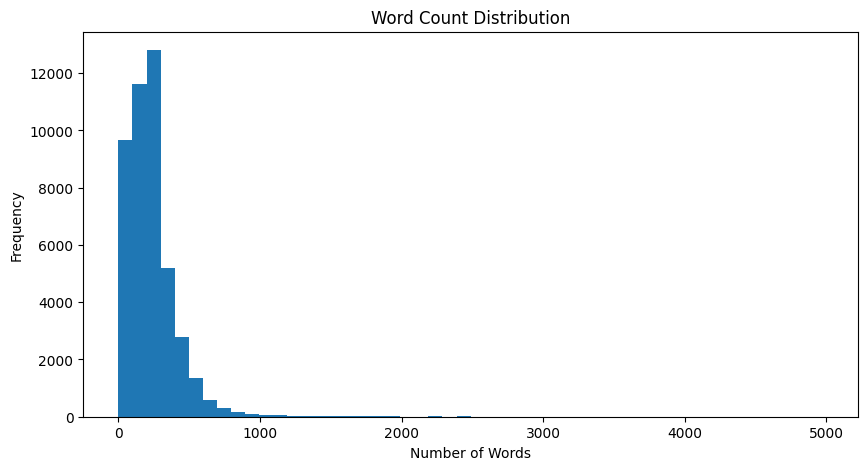

In [22]:
# Word Count Distribution
plt.figure(figsize=(10,5))

plt.hist(
    df["word_count"],
    bins=50
)

plt.title(
    "Word Count Distribution"
)

plt.xlabel(
    "Number of Words"
)

plt.ylabel(
    "Frequency"
)

plt.show()

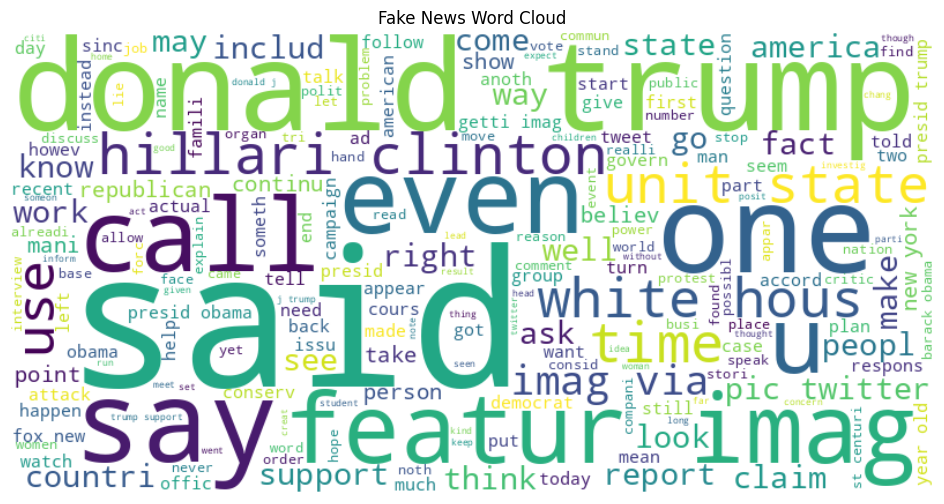

In [23]:
# Fake News Word Cloud
fake_words = " ".join(
    df[df["label"] == 0]
    ["clean_text"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(fake_words)

plt.figure(figsize=(12,6))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Fake News Word Cloud"
)

plt.show()

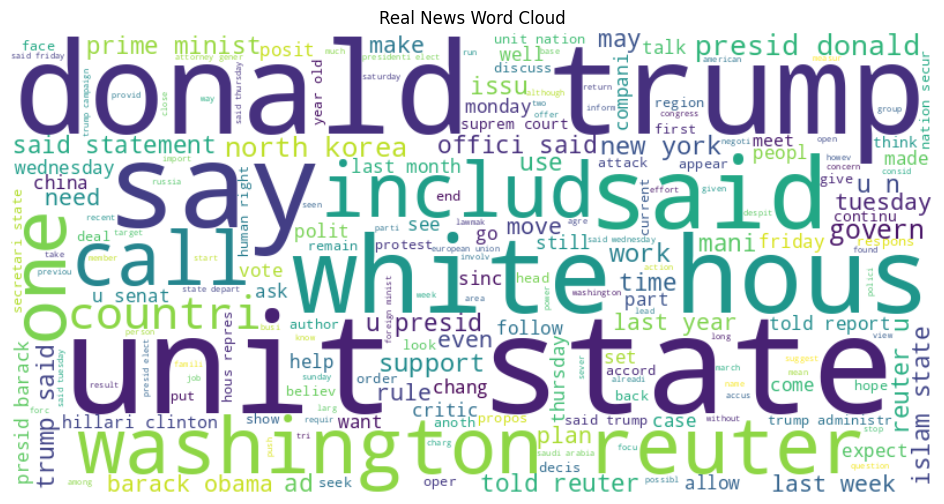

In [24]:
# Real News Word Cloud
real_words = " ".join(
    df[df["label"] == 1]
    ["clean_text"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(real_words)

plt.figure(figsize=(12,6))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Real News Word Cloud"
)

plt.show()

In [25]:
# Train Test Split
X = df["clean_text"]

y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=10000
)

X_train_tfidf = vectorizer.fit_transform(
    X_train
)

X_test_tfidf = vectorizer.transform(
    X_test
)

print(
    X_train_tfidf.shape
)

(35918, 10000)


In [31]:
# Train Logistic Regression
lr_model = LogisticRegression()

lr_model.fit(
    X_train_tfidf,
    y_train
)

lr_predictions = lr_model.predict(
    X_test_tfidf
)

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print(
    "Logistic Regression Accuracy:",
    round(lr_accuracy * 100, 2),
    "%"
)

Logistic Regression Accuracy: 98.42 %


In [32]:
# Train Naive Bayes
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_predictions = nb_model.predict(
    X_test_tfidf
)

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

print(
    "Naive Bayes Accuracy:",
    round(nb_accuracy * 100, 2),
    "%"
)

Naive Bayes Accuracy: 92.72 %


In [33]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_tfidf,
    y_train
)

rf_predictions = rf_model.predict(
    X_test_tfidf
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

Random Forest Accuracy: 99.55 %


In [34]:
# Train SVM
svm_model = LinearSVC()

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_predictions = svm_model.predict(
    X_test_tfidf
)

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print(
    "SVM Accuracy:",
    round(svm_accuracy * 100, 2),
    "%"
)

SVM Accuracy: 99.37 %


In [35]:
# Compare Models
results = pd.DataFrame(
    {
        "Model":[
            "Logistic Regression",
            "Naive Bayes",
            "Random Forest",
            "SVM"
        ],
        "Accuracy":[
            lr_accuracy,
            nb_accuracy,
            rf_accuracy,
            svm_accuracy
        ]
    }
)

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

,Model,Accuracy
2,Random Forest,0.995546
3,SVM,0.993653
0,Logistic Regression,0.984187
1,Naive Bayes,0.927171


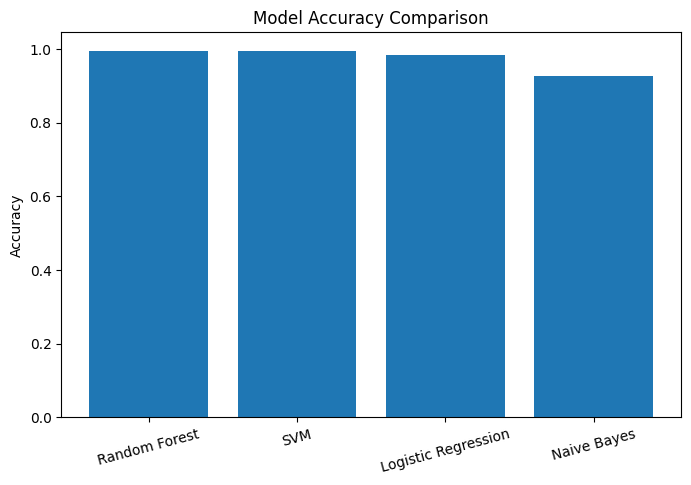

In [36]:
# Accuracy Comparison Chart
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title(
    "Model Accuracy Comparison"
)

plt.ylabel(
    "Accuracy"
)

plt.xticks(rotation=15)

plt.show()

In [37]:
# Best Model
best_model_name = results.iloc[0]["Model"]

print(
    "Best Model:",
    best_model_name
)

Best Model: Random Forest


In [38]:
# Classification Report
print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4710
           1       1.00      0.99      1.00      4270

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



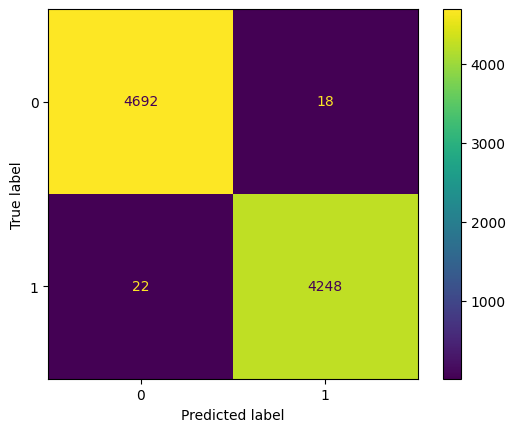

In [58]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    rf_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [51]:
# Cross Validation
from sklearn.model_selection import StratifiedKFold

rf_model_cv = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

accuracies = []

print("Performing 5-fold cross-validation for Random Forest...")

for fold, (train_index, val_index) in enumerate(kf.split(X_train_tfidf, y_train)):
    X_train_fold, X_val_fold = X_train_tfidf[train_index], X_train_tfidf[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    rf_model_cv.fit(X_train_fold, y_train_fold)
    fold_predictions = rf_model_cv.predict(X_val_fold)
    fold_accuracy = accuracy_score(y_val_fold, fold_predictions)
    accuracies.append(fold_accuracy)
    print(f"Fold {fold+1} Accuracy: {round(fold_accuracy * 100, 2)}%")

average_accuracy = np.mean(accuracies)
print(f"\nAverage Cross-Validation Accuracy: {round(average_accuracy * 100, 2)}%")

Performing 5-fold cross-validation for Random Forest...
Fold 1 Accuracy: 99.67%
Fold 2 Accuracy: 99.71%
Fold 3 Accuracy: 99.46%
Fold 4 Accuracy: 99.43%
Fold 5 Accuracy: 99.44%

Average Cross-Validation Accuracy: 99.54%


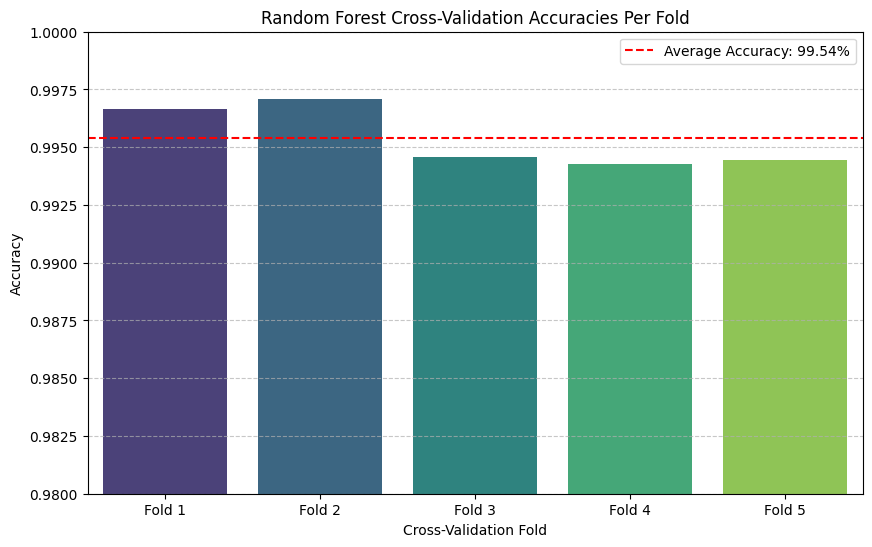

In [54]:
plt.figure(figsize=(10, 6))
sns.barplot(x=[f'Fold {i+1}' for i in range(len(accuracies))], y=accuracies, palette='viridis')
plt.axhline(average_accuracy, color='red', linestyle='--', label=f'Average Accuracy: {round(average_accuracy * 100, 2)}%')
plt.title('Random Forest Cross-Validation Accuracies Per Fold')
plt.xlabel('Cross-Validation Fold')
plt.ylabel('Accuracy')
plt.ylim(0.98, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [40]:
# Top Fake-News Keywords
feature_names = np.array(
    vectorizer.get_feature_names_out()
)

top_fake = np.argsort(
    lr_model.coef_[0]
)[:20]

print(
    "Top Fake News Keywords:\n"
)

for word in feature_names[top_fake]:
    print(word)

Top Fake News Keywords:

via
imag
us
read
mr
gop
featur
wire
hillari
com
even
america
american
sen
pic
obama
rep
getti
watch
like


In [41]:
# Top Real-News Keywords
top_real = np.argsort(
    lr_model.coef_[0]
)[-20:]

print(
    "Top Real News Keywords:\n"
)

for word in reversed(
    feature_names[top_real]
):
    print(word)

Top Real News Keywords:

reuter
said
washington
wednesday
tuesday
thursday
friday
monday
minist
nov
presidenti
told
edt
spokesman
statement
repres
london
republican
rival
senat


In [59]:
# Interactive News Predictor
news = input(
    "Enter News Article or Headline:\n"
)

clean_news = clean_text(
    news
)

vector = vectorizer.transform(
    [clean_news]
)

prediction = rf_model.predict(
    vector
)[0]

if prediction == 1:
    print(
        "\n✅ REAL NEWS"
    )
else:
    print(
        "\n❌ FAKE NEWS"
    )

Enter News Article or Headline:
Click here to claim the Iphone

❌ FAKE NEWS


In [62]:
# Confidence Score
probabilities = rf_model.predict_proba(vector)[0]

# Get the probability of the predicted class
confidence = probabilities[prediction] * 100

print(
    f"Confidence: {confidence:.2f}%"
)

Confidence: 99.86%


In [66]:
# Save Model
import joblib

joblib.dump(
    rf_model,
    "fake_news_model.pkl"
)

print(
    "Model Saved"
)

Model Saved


In [67]:
# Save TF-IDF Vectorizer
joblib.dump(
    vectorizer,
    "tfidf_vectorizer.pkl"
)

print(
    "Vectorizer Saved"
)

Vectorizer Saved
